In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [4]:
# ===============================
# Import Required Libraries
# ===============================

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [5]:
# Load dataset

df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 284807
Columns : 31


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,-0.371407,1.341262,0.359894,-0.358091,-0.137134,0.517617,0.401726,-0.058133,0.068653,-0.033194,0.084968,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,-0.099254,-1.416907,-0.153826,-0.751063,0.167372,0.050144,-0.443587,0.002821,-0.611987,-0.045575,-0.219633,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,1.249376,-0.619468,0.291474,1.757964,-1.323865,0.686133,-0.076127,-1.222127,-0.358222,0.324505,-0.156742,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,-0.410430,-0.705117,-0.110452,-0.286254,0.074355,-0.328783,-0.210077,-0.499768,0.118765,0.570328,0.052736,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,-0.366846,1.017614,0.836390,1.006844,-0.443523,0.150219,0.739453,-0.540980,0.476677,0.451773,0.203711,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [11]:
missing = df.isnull().sum()

missing

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [12]:
print("Total Missing Values:", missing.sum())

Total Missing Values: 0


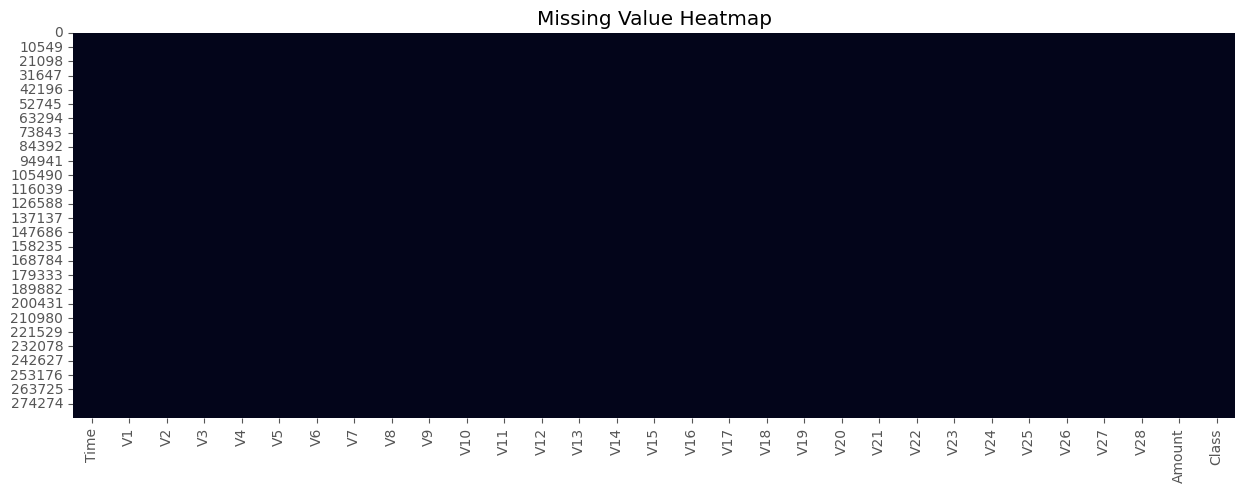

In [13]:
plt.figure(figsize=(15,5))

sns.heatmap(df.isnull(),
            cbar=False)

plt.title("Missing Value Heatmap")

plt.show()

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 1081


In [13]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [14]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [15]:
percentage = df['Class'].value_counts(normalize=True)*100

percentage

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

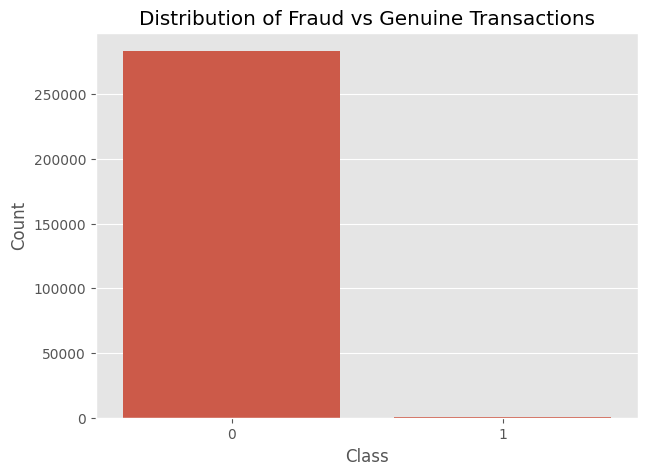

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='Class')

plt.title("Distribution of Fraud vs Genuine Transactions")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

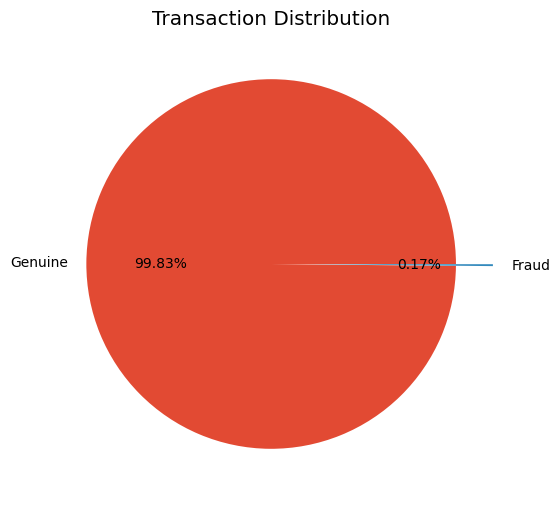

In [19]:
df['Class'].value_counts().plot(
    kind='pie',
    labels=['Genuine','Fraud'],
    autopct='%1.2f%%',
    explode=[0,0.2]
)

plt.title("Transaction Distribution")

plt.ylabel("")

plt.show()

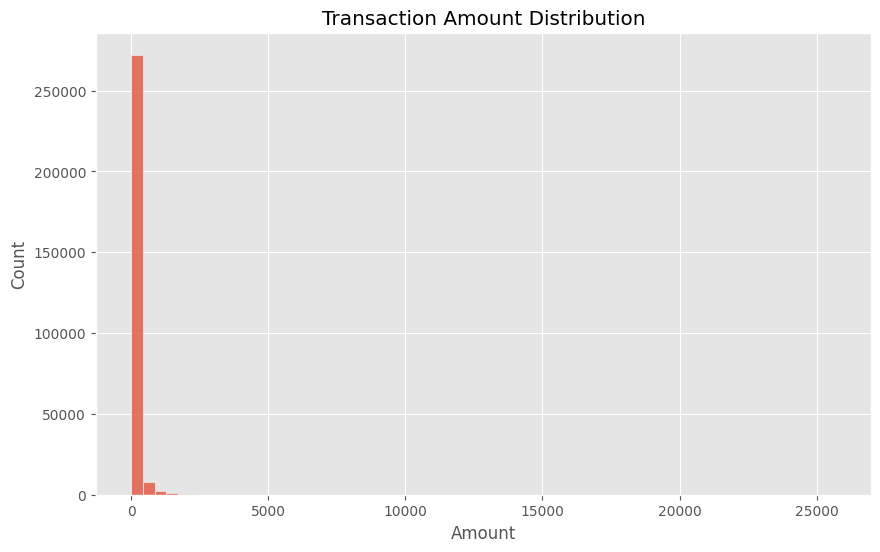

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df['Amount'],
             bins=60)

plt.title("Transaction Amount Distribution")

plt.show()

In [21]:
print(df['Amount'].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


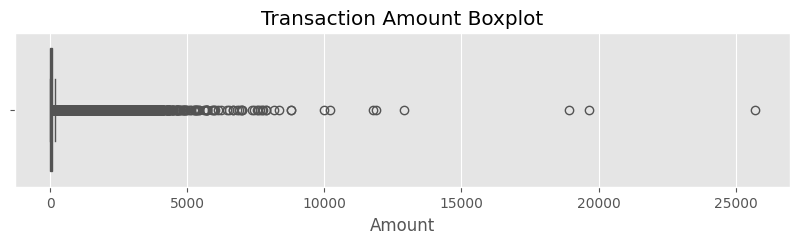

In [22]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df['Amount'])

plt.title("Transaction Amount Boxplot")

plt.show()

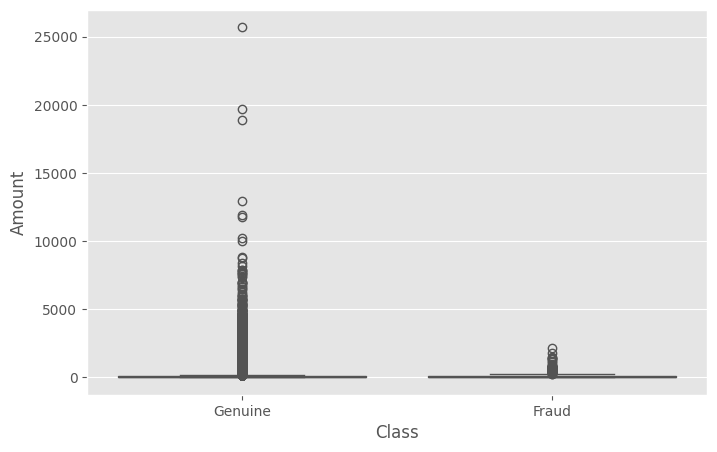

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df
)

plt.xticks([0,1],['Genuine','Fraud'])

plt.show()

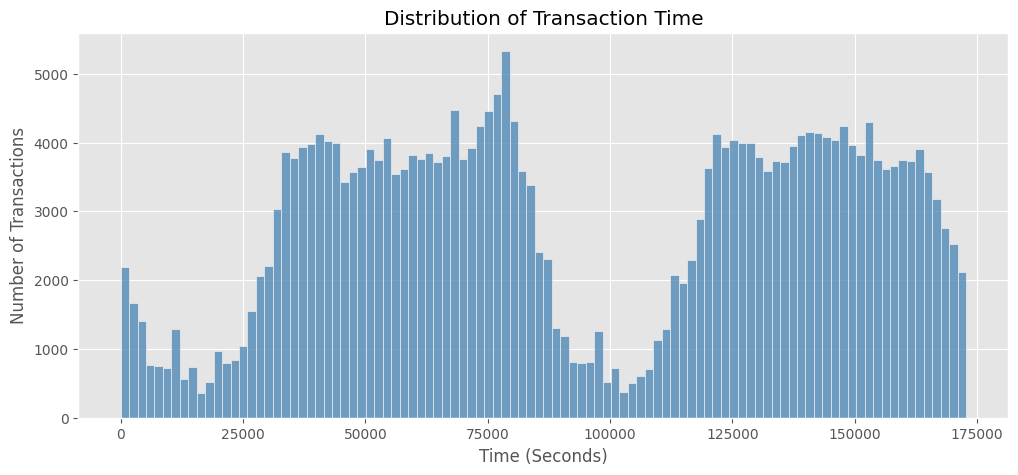

In [24]:
plt.figure(figsize=(12,5))

sns.histplot(df["Time"], bins=100, color="steelblue")

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Number of Transactions")

plt.show()

In [16]:
df["Hour"] = (df["Time"] // 3600) % 24

df[["Time", "Hour"]].head()

,Time,Hour
0,0.0,0.0
1,0.0,0.0
2,1.0,0.0
3,1.0,0.0
4,2.0,0.0


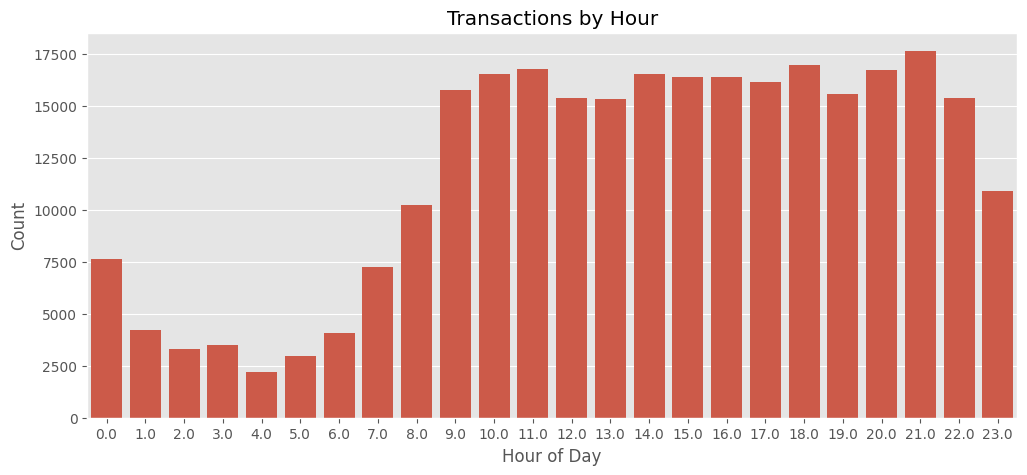

In [17]:
plt.figure(figsize=(12,5))

sns.countplot(x="Hour", data=df)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.show()

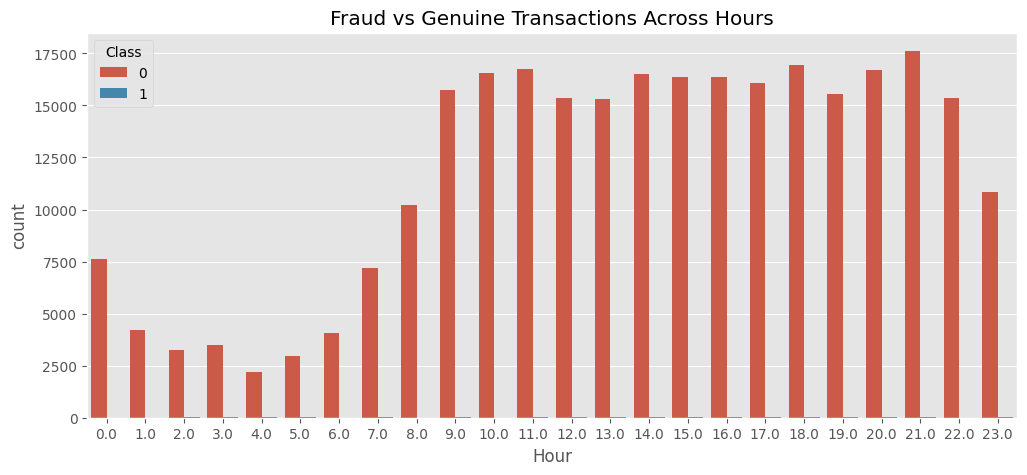

In [18]:
plt.figure(figsize=(12,5))

sns.countplot(
    x="Hour",
    hue="Class",
    data=df
)

plt.title("Fraud vs Genuine Transactions Across Hours")

plt.show()

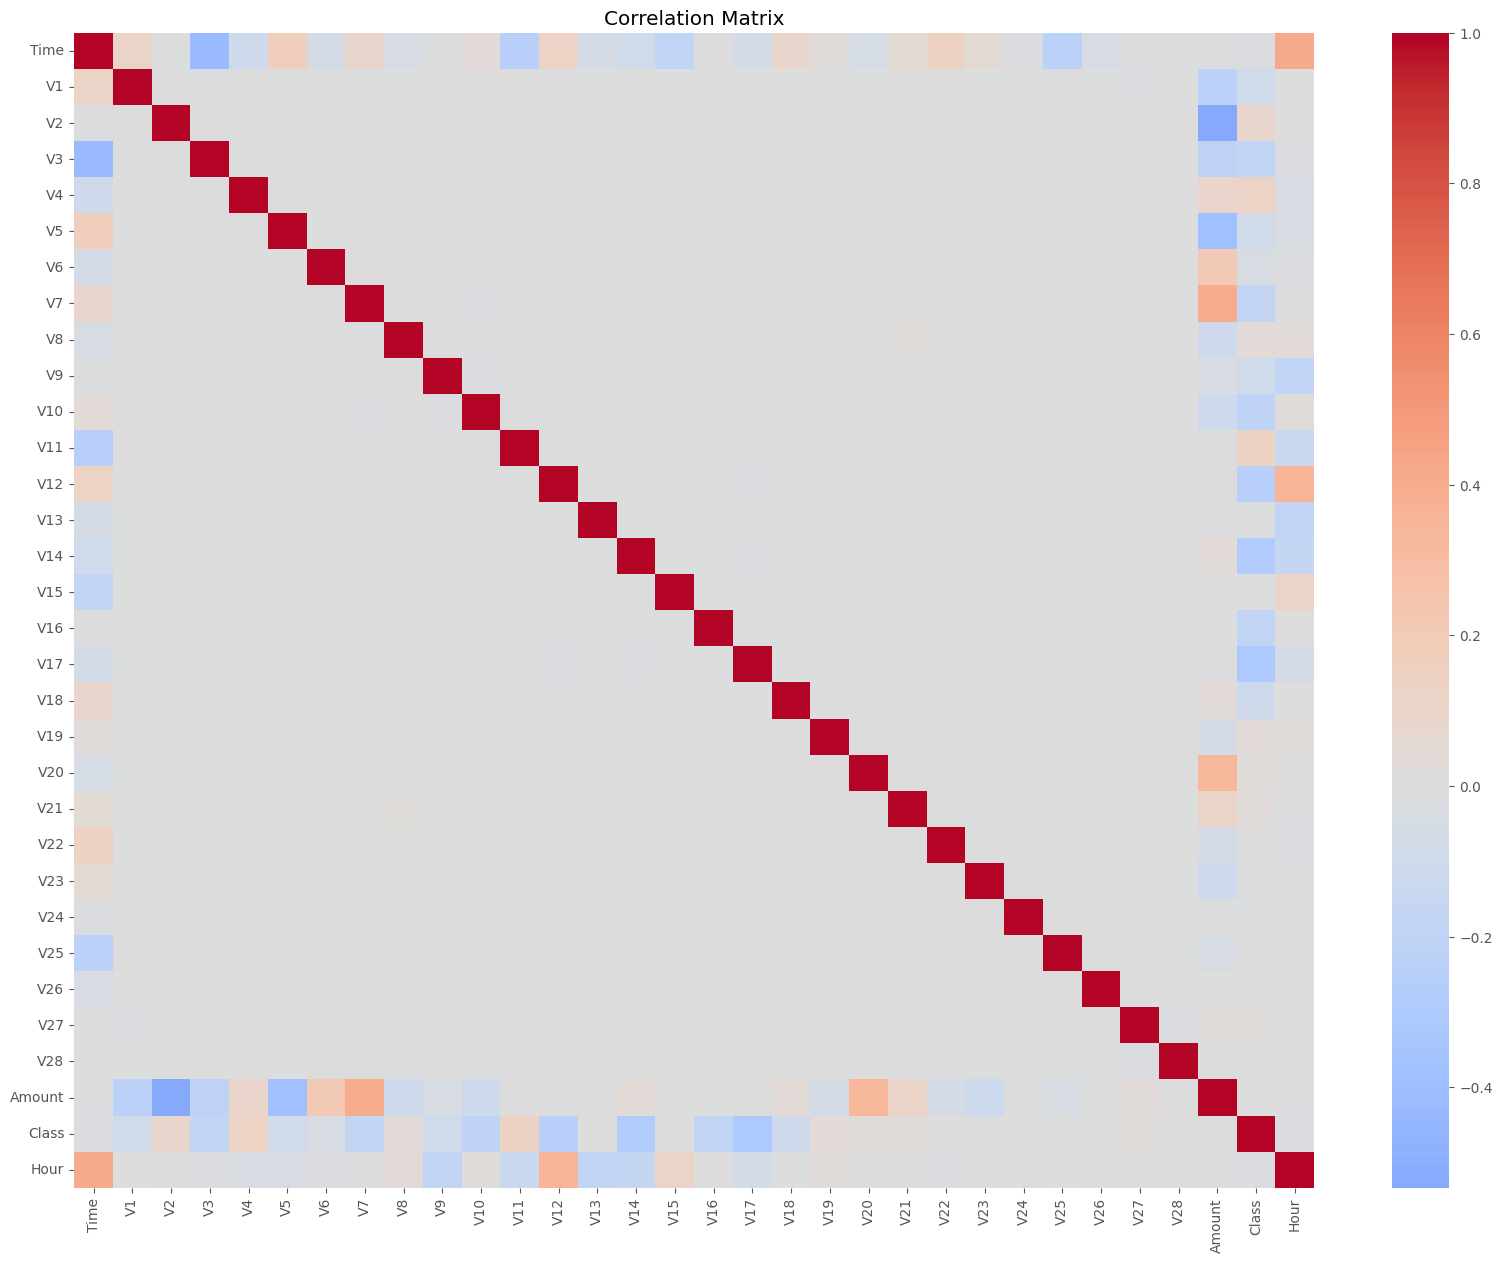

In [28]:
plt.figure(figsize=(20,15))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
corr_target = df.corr()["Class"].sort_values(ascending=False)

corr_target

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
Hour     -0.016740
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

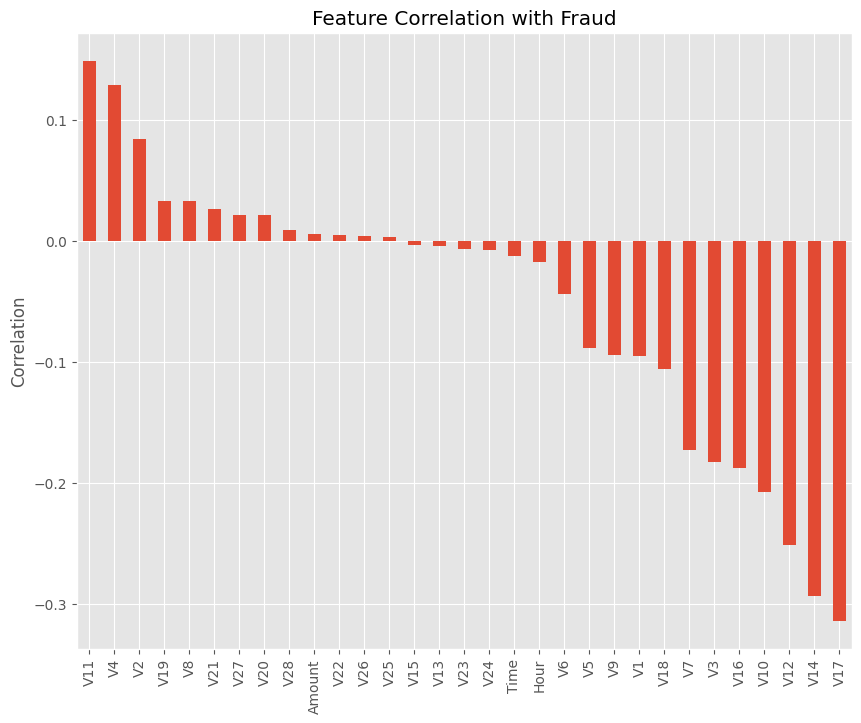

In [37]:
plt.figure(figsize=(10,8))

corr_target.drop("Class").plot(kind="bar")

plt.title("Feature Correlation with Fraud")

plt.ylabel("Correlation")

plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Scaled_Amount"] = scaler.fit_transform(df[["Amount"]])

df["Scaled_Time"] = scaler.fit_transform(df[["Time"]])

In [21]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour,Scaled_Amount,Scaled_Time
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.244200,-1.996823
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,-0.342584,-1.996823
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,1.158900,-1.996802
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.139886,-1.996802
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,-0.073813,-1.996781


In [22]:
df = df.drop(["Amount", "Time"], axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Hour,Scaled_Amount,Scaled_Time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0,-0.073813,-1.996781


In [23]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (283726, 31)
Target Shape : (283726,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (226980, 31)
Testing Samples : (56746, 31)


In [26]:
print("Training Distribution")

print(y_train.value_counts(normalize=True))

print()

print("Testing Distribution")

print(y_test.value_counts(normalize=True))

Training Distribution
Class
0    0.998335
1    0.001665
Name: proportion, dtype: float64

Testing Distribution
Class
0    0.998326
1    0.001674
Name: proportion, dtype: float64


In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [29]:
print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64


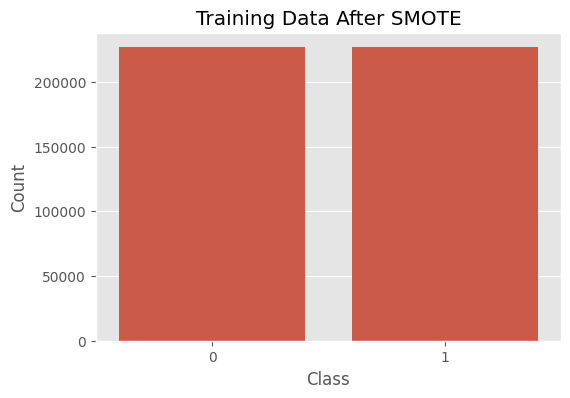

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title("Training Data After SMOTE")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [32]:
results = []

def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        roc = np.nan

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": type(model).__name__,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC AUC": roc
    })

    print(classification_report(y_test, y_pred))

In [33]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

evaluate_model(
    lr,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [34]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.36      0.71      0.47        95

    accuracy                           1.00     56746
   macro avg       0.68      0.85      0.74     56746
weighted avg       1.00      1.00      1.00     56746



In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

evaluate_model(
    rf,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [36]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,RandomForestClassifier,0.999436,0.898734,0.747368,0.816092,0.963367
1,DecisionTreeClassifier,0.997374,0.356383,0.705263,0.473498,0.851564
0,LogisticRegression,0.973584,0.052866,0.873684,0.099700,0.965737


In [37]:
from xgboost import XGBClassifier

In [38]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

evaluate_model(
    xgb,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.62      0.81      0.70        95

    accuracy                           1.00     56746
   macro avg       0.81      0.90      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [39]:
from lightgbm import LGBMClassifier

In [40]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

evaluate_model(
    lgbm,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.060513 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.68      0.79      0.73        95

    accuracy                           1.00     56746
   macro avg       0.84      0.89      0.87     56746
weighted avg       1.00      1.00      1.00     56746



In [43]:
from catboost import CatBoostClassifier

In [45]:
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    verbose=0,
    random_state=42
)

evaluate_model(
    cat,
    X_train_smote,
    y_train_smote,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.46      0.80      0.58        95

    accuracy                           1.00     56746
   macro avg       0.73      0.90      0.79     56746
weighted avg       1.00      1.00      1.00     56746



In [46]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
2,RandomForestClassifier,0.999436,0.898734,0.747368,0.816092,0.963367
4,LGBMClassifier,0.999031,0.681818,0.789474,0.731707,0.963883
3,XGBClassifier,0.998855,0.620968,0.810526,0.703196,0.973027
5,CatBoostClassifier,0.998079,0.457831,0.800000,0.582375,0.960050
6,CatBoostClassifier,0.998079,0.457831,0.800000,0.582375,0.960050
1,DecisionTreeClassifier,0.997374,0.356383,0.705263,0.473498,0.851564
0,LogisticRegression,0.973584,0.052866,0.873684,0.099700,0.965737


In [47]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [51]:
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

In [53]:
from sklearn.model_selection import train_test_split

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=30000,
    stratify=y_train_smote,
    random_state=42
)

print(X_tune.shape)

(30000, 31)


In [54]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring="f1",
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_tune, y_tune)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'bootstrap': [True],
                                        'max_depth': [10, 20, None],
                                        'max_features': ['sqrt'],
                                        'min_samples_leaf': [1, 2],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [200, 300, 500]},
                   random_state=42, scoring='f1', verbose=2)

In [55]:
print("Best Parameters Found:\n")
print(random_search.best_params_)

Best Parameters Found:

{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [56]:
best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

# Train on the COMPLETE SMOTE dataset
best_rf.fit(X_train_smote, y_train_smote)

print(best_rf)

[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 1.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=  25.9s
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=5, n_estimators=500; total time= 1.1min
[CV] END bootstrap=True, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.1min
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=  36.5s
[CV] END bootstrap=True, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=300; total time=  41.6s
[CV] END bootstrap=True, max_depth=20,

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:,1]

print("Accuracy :", round(accuracy_score(y_test, y_pred),4))
print("Precision:", round(precision_score(y_test, y_pred),4))
print("Recall   :", round(recall_score(y_test, y_pred),4))
print("F1 Score :", round(f1_score(y_test, y_pred),4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob),4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9994
Precision: 0.8987
Recall   : 0.7474
F1 Score : 0.8161
ROC AUC  : 0.9712

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.90      0.75      0.82        95

    accuracy                           1.00     56746
   macro avg       0.95      0.87      0.91     56746
weighted avg       1.00      1.00      1.00     56746



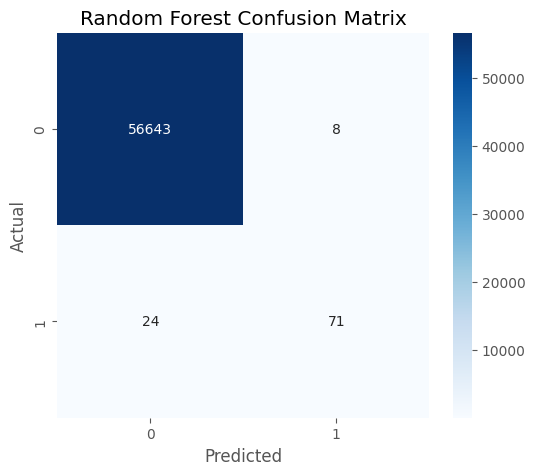

In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [59]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
13,V14,0.189599
9,V10,0.127302
16,V17,0.106465
11,V12,0.103678
3,V4,0.092670
10,V11,0.067618
15,V16,0.039266
2,V3,0.033887
6,V7,0.030632
1,V2,0.026298


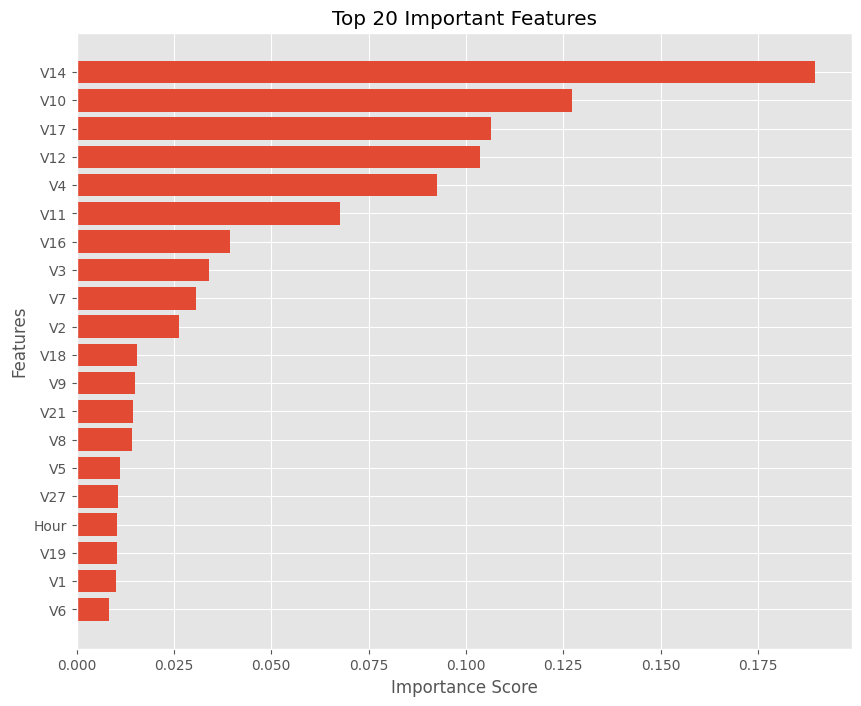

In [60]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 20 Important Features")

plt.show()

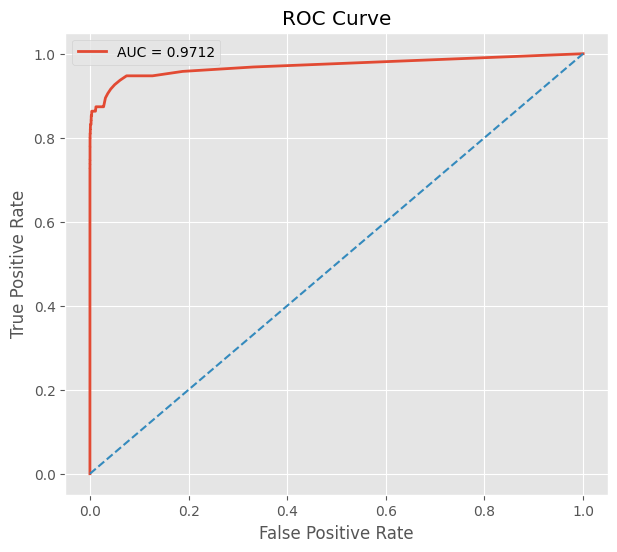

In [61]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

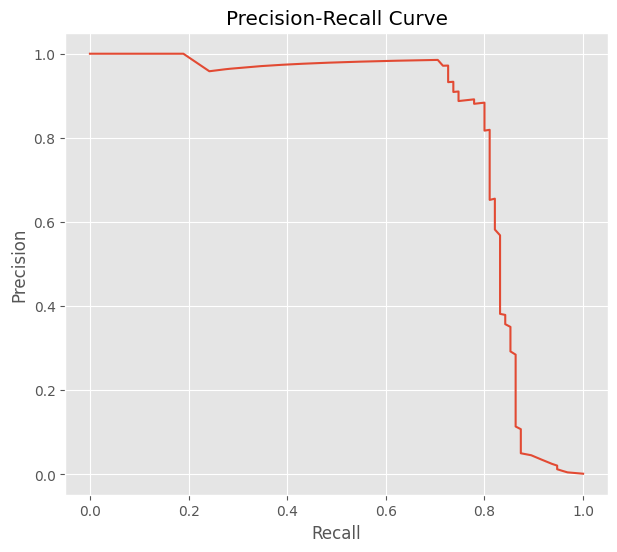

In [62]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [63]:
thresholds = np.arange(0.1,0.91,0.05)

scores=[]

for t in thresholds:

    pred=(y_prob>=t).astype(int)

    scores.append([
        t,
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

threshold_df=pd.DataFrame(
    scores,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.381643,0.831579,0.523179
1,0.15,0.614173,0.821053,0.702703
2,0.20,0.719626,0.810526,0.762376
3,0.25,0.777778,0.810526,0.793814
4,0.30,0.817204,0.800000,0.808511
5,0.35,0.853933,0.800000,0.826087
6,0.40,0.890244,0.768421,0.824859
7,0.45,0.887500,0.747368,0.811429
8,0.50,0.898734,0.747368,0.816092
9,0.55,0.921053,0.736842,0.818713


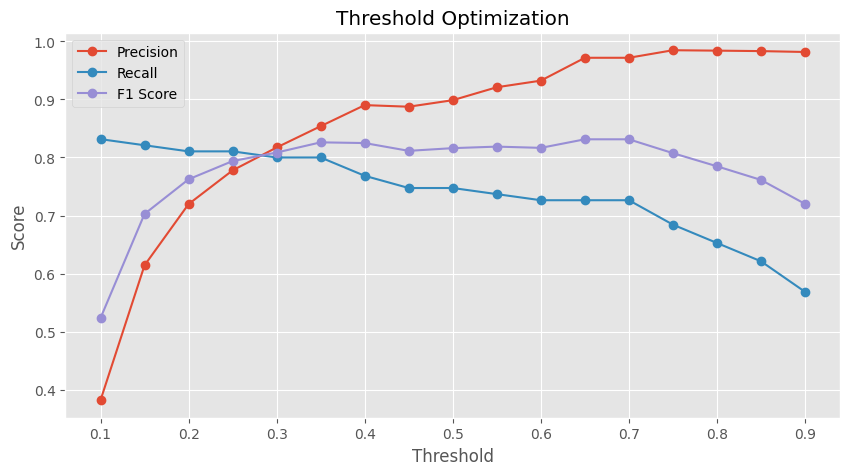

In [64]:
plt.figure(figsize=(10,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

In [69]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
})

final_results

,Metric,Value
0,Accuracy,0.999436
1,Precision,0.898734
2,Recall,0.747368
3,F1 Score,0.816092
4,ROC AUC,0.971167


In [70]:
import joblib

joblib.dump(best_rf, "best_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!
